In [1]:
"""
plot_day_hawkes.py -- day visualisation of the Stage 2 Hawkes results.

CONTRACT
  raw, bars, events, pred, res_frozen are all pre-sliced to one date.
  timestamp is the only join key. bar_index is never read.

PANES
  1  OHLC + JMA coloured by leg direction, JMA dots coloured by calibrated
     per-bar hazard, markers at true JMA extrema.
  2  jmaD1 / jmaD2 with pivot markers (red = opposing the leg, green = confirming).
  3  tickJmaD1 / tickJmaD2, same marker convention.
  4  Hazard pane: calibrated per-bar hazard, frozen-path pbreak(H), direct
     within-H break probability. Dashed line = unconditional base rate.

NOTES
  P1  A target event at bar t means the JMA extremum sits at bar t-1. Markers are
      drawn at extremum_timestamp (what the eye sees); the turn is only knowable
      one bar later.
  P2  pcont_hawkes uses the raw (uncalibrated) model internally, so pbreak_frozen
      is on the raw scale. Meaningful for H = 1..3 only.
  P3  ~395 target pivots per 6s session. Slice a window; a whole day is unreadable.
"""

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

BASE_RATE = 0.10302

BARS_COLS = ["timestamp", "jma_leg_dir", "leg_age", "is_target", "warm"]

In [2]:
def build_day_frame(raw, bars, events, pred=None, res_frozen=None,
                    hazard_col="p_cal", within_col="p_cal2"):
    d = raw.merge(bars[BARS_COLS], on="timestamp", how="inner")

    if pred is not None:
        take = ["timestamp"]
        ren = {}
        if hazard_col in pred.columns:
            take.append(hazard_col)
            ren[hazard_col] = "hazard"
        if within_col in pred.columns:
            take.append(within_col)
            ren[within_col] = "p_within"
        d = d.merge(pred[take].rename(columns=ren), on="timestamp", how="left")

    if res_frozen is not None:
        d = d.merge(res_frozen[["timestamp", "pbreak"]].rename(
            columns={"pbreak": "pbreak_frozen"}), on="timestamp", how="left")

    return d.sort_values("timestamp").reset_index(drop=True), events

In [29]:
def _seg(y, mask):
    out = np.full(len(y), np.nan)
    out[mask] = y[mask]
    return out


def _markers(fig, ev, stream, row, size=7):
    e = ev[ev["stream"] == stream]
    if len(e) == 0:
        return
    for opp, colour, nm in ((1, "#d62728", "opp"), (-1, "#2ca02c", "conf")):
        s = e[e["opposing"] == opp]
        if len(s) == 0:
            continue
        sym = np.where(s["polarity"] == 1, "triangle-down", "triangle-up")
        fig.add_trace(go.Scattergl(
            x=s["extremum_timestamp"], y=s["value"], mode="markers",      # P1
            name=f"{stream} {nm}",
            marker=dict(color=colour, size=size, symbol=sym,
                        line=dict(width=0.5, color="black")),
            legendgroup=stream), row=row, col=1)


def plot_day_hawkes(d, ev, t_from=None, t_to=None, height=1400, width=2400):
    if t_from is not None:
        t_from = pd.Timestamp(t_from).time() if isinstance(t_from, str) else t_from
        d = d[d["timestamp"].dt.time >= t_from]                            # P3
    if t_to is not None:
        t_to = pd.Timestamp(t_to).time() if isinstance(t_to, str) else t_to
        d = d[d["timestamp"].dt.time <= t_to]
    lo, hi = d["timestamp"].iloc[0], d["timestamp"].iloc[-1]
    ev = ev[ev["extremum_timestamp"].between(lo, hi)]

    x = d["timestamp"]
    fig = make_subplots(rows=4, cols=1, shared_xaxes=True, vertical_spacing=0.025,
                        row_heights=[0.42, 0.18, 0.18, 0.22],
                        subplot_titles=["OHLC + JMA (dot colour = calibrated hazard)",
                                        "MNQ JMA derivatives",
                                        "TICK JMA derivatives",
                                        "Break probability"])

    fig.add_trace(go.Ohlc(x=x, open=d["Open"], high=d["High"], low=d["Low"],
                          close=d["Last"], name="OHLC", opacity=0.45,
                          increasing_line_color="#7f7f7f",
                          decreasing_line_color="#7f7f7f"), row=1, col=1)

    up = d["jma_leg_dir"].to_numpy() == 1
    dn = d["jma_leg_dir"].to_numpy() == -1
    jma = d["JMA"].to_numpy()
    fig.add_trace(go.Scattergl(x=x, y=_seg(jma, up), mode="lines", name="JMA up",
                               line=dict(width=2, color="#2ca02c")), row=1, col=1)
    fig.add_trace(go.Scattergl(x=x, y=_seg(jma, dn), mode="lines", name="JMA dn",
                               line=dict(width=2, color="#d62728")), row=1, col=1)

    if "hazard" in d.columns:
        fig.add_trace(go.Scattergl(
            x=x, y=jma, mode="markers", name="hazard",
            marker=dict(size=5, color=d["hazard"], colorscale="Turbo",
                        cmin=0.0, cmax=0.30, showscale=True,
                        #colorbar=dict(title="p(bar)", len=0.35, y=0.82))),
                        colorbar=dict(
                            title="p(bar)",
                            len=0.35,
                            y=0.82,
                            x=1.08,
                            xanchor="left",
                            thickness=18,
                        ))),                      
            row=1, col=1)

    _markers(fig, ev, "MNQ_JMA_SELF", 1, size=9)

    for c, w in (("jmaD1", 1.6), ("jmaD2", 1.2)):
        fig.add_trace(go.Scattergl(x=x, y=d[c], mode="lines", name=c,
                                   line=dict(width=w)), row=2, col=1)
    _markers(fig, ev, "MNQ_D1", 2)
    _markers(fig, ev, "MNQ_D2", 2, size=5)

    for c, w in (("tickJmaD1", 1.6), ("tickJmaD2", 1.2)):
        fig.add_trace(go.Scattergl(x=x, y=d[c], mode="lines", name=c,
                                   line=dict(width=w)), row=3, col=1)
    _markers(fig, ev, "TICK_D1", 3)
    _markers(fig, ev, "TICK_D2", 3, size=5)

    if "hazard" in d.columns:
        fig.add_trace(go.Scattergl(x=x, y=d["hazard"], mode="lines",
                                   name="hazard (1 bar, cal)",
                                   line=dict(width=1.5, color="#1f77b4")), row=4, col=1)
    if "pbreak_frozen" in d.columns:
        fig.add_trace(go.Scattergl(x=x, y=d["pbreak_frozen"], mode="lines",
                                   name="pbreak frozen (raw)",              # P2
                                   line=dict(width=1.2, color="#ff7f0e", dash="dot")),
                      row=4, col=1)
    if "p_within" in d.columns:
        fig.add_trace(go.Scattergl(x=x, y=d["p_within"], mode="lines",
                                   name="pbreak<=H (direct)",
                                   line=dict(width=1.2, color="#9467bd")), row=4, col=1)

    fig.add_hline(y=BASE_RATE, line=dict(color="black", dash="dash", width=1), row=4, col=1)

    s = ev[ev["stream"] == "MNQ_JMA_SELF"]
    if len(s):
        fig.add_trace(go.Scattergl(x=s["extremum_timestamp"], y=np.zeros(len(s)),
                                   mode="markers", name="JMA pivot",
                                   marker=dict(symbol="line-ns-open", size=10,
                                               color="black", line=dict(width=1))),
                      row=4, col=1)

    fig.update_layout(height=height, width=width, template="plotly_white",
                      hovermode="x unified", xaxis_rangeslider_visible=False,
                      margin=dict(l=5, r=5, t=20, b=5),
                      legend=dict(
                          groupclick="toggleitem",
                          x=1.12,
                          y=1.0,
                          xanchor="left",
                          yanchor="top",
                      ))
    fig.update_yaxes(title_text="Price", row=1, col=1)
    fig.update_yaxes(title_text="D1 / D2", row=2, col=1)
    fig.update_yaxes(title_text="TICK D1 / D2", row=3, col=1)
    fig.update_yaxes(title_text="P(break)", range=[0, 1], row=4, col=1)
    fig.update_xaxes(title_text="Time", row=4, col=1)
    #fig.show()
    return fig

In [4]:
def add_hazard_bands(fig, d, thresh, row=1):
    hot = (d["hazard"].fillna(0) >= thresh).to_numpy()
    if not hot.any():
        return fig
    edges = np.diff(np.concatenate(([0], hot.astype(np.int8), [0])))
    for s, e in zip(np.nonzero(edges == 1)[0], np.nonzero(edges == -1)[0] - 1):
        fig.add_vrect(x0=d["timestamp"].iloc[s], x1=d["timestamp"].iloc[e],
                      fillcolor="red", opacity=0.10, line_width=0, row=row, col=1)
    return fig

In [5]:
# Configuration: Style preferences
#plt.style.use('ggplot') # Good default for readability
pd.set_option("display.width", 400)      # total characters per line
pd.set_option("display.max_columns", 30) # prevent wrapping by limiting columns
pd.set_option("display.max_rows", 1000)

In [6]:
FRAME=6
HORIZON = 8
OUT_DIR='data/stage-2'

day = pd.Timestamp('2025-03-20').date()

rawFile= f'data/mnq-tick-oscillator-6sec.pqt'
raw = pd.read_parquet(rawFile)
raw = raw[raw["timestamp"].dt.date == pd.Timestamp(day).date()]
raw = raw[raw["timestamp"].dt.time >= pd.Timestamp("09:30").time()]

bars = pd.read_parquet(f'data/stage-0/bars_{FRAME}s.parquet')
bars = bars[bars["timestamp"].dt.date == pd.Timestamp(day).date()]
bars = bars[bars["timestamp"].dt.time >= pd.Timestamp("09:30").time()]

events = pd.read_parquet(f'data/stage-0/events_{FRAME}s.parquet')
events = events[events["timestamp"].dt.date == pd.Timestamp(day).date()]
events = events[events["timestamp"].dt.time >= pd.Timestamp("09:30").time()]

pred = pd.read_parquet(f"{OUT_DIR}/pred-iso-calibrated2-{HORIZON}h.parquet")
pred = pred[pred["timestamp"].dt.date == pd.Timestamp(day).date()]
pred = pred[pred["timestamp"].dt.time >= pd.Timestamp("09:30").time()]

frozen = pd.read_parquet(f"{OUT_DIR}/pred-frozen-3h.parquet")
frozen = frozen[frozen["timestamp"].dt.date == pd.Timestamp(day).date()]
frozen = frozen[frozen["timestamp"].dt.time >= pd.Timestamp("09:30").time()]


In [7]:
print('\n-----------------------------------------------')
print(len(raw))
print(raw.head())
print('\n-----------------------------------------------')
print(len(bars))
print(bars.head())
print('\n-----------------------------------------------')
print(len(events))
print(events.head())
print('\n-----------------------------------------------')
print(len(pred))
print(pred.head())
print('\n-----------------------------------------------')
print(len(frozen))
print(frozen.head())


-----------------------------------------------
3900
                  timestamp          Open          High       Low        Last           JMA       VEL    adpVEL  bolTopAdpVEL  bolMidAdpVEL  bolBotAdpVEL        RSX    tickRSX      jmaD1     jmaD2  bolTopJmaD2  bolMidJmaD2  bolBotJmaD2   tickJmaD1   tickJmaD2  bolTopTickJmaD2  bolMidTickJmaD2  bolBotTickJmaD2     tickJMA       date
3176810 2025-03-20 09:30:00  19785.343750  19787.750000  19770.00  19780.9375  19784.099609 -0.382195 -0.455477      0.494734     -0.339085     -1.172904 -89.096771 -33.962200  -0.765625  1.208984     1.364854    -0.010254    -1.385362 -102.979248  -73.155975        16.969612        -1.392377       -19.754368 -575.801147 2025-03-20
3176811 2025-03-20 09:30:06  19783.140625  19783.250000  19775.25  19779.0000  19782.748047 -0.384536 -0.445870      0.486274     -0.344772     -1.175817 -81.643143 -51.110668  -1.921875 -0.642578     1.364437     0.005039    -1.354358 -149.083160 -138.263062        20.078993  

In [17]:
#d, ev = build_day_frame(raw, bars, events, pred=pred)      # p_cal -> hazard, p_cal2 -> p_within
d, ev = build_day_frame(raw, bars, events, pred=pred, res_frozen=frozen)

#fig = plot_day_hawkes(d, ev, t_from="10:30", t_to="11:20")

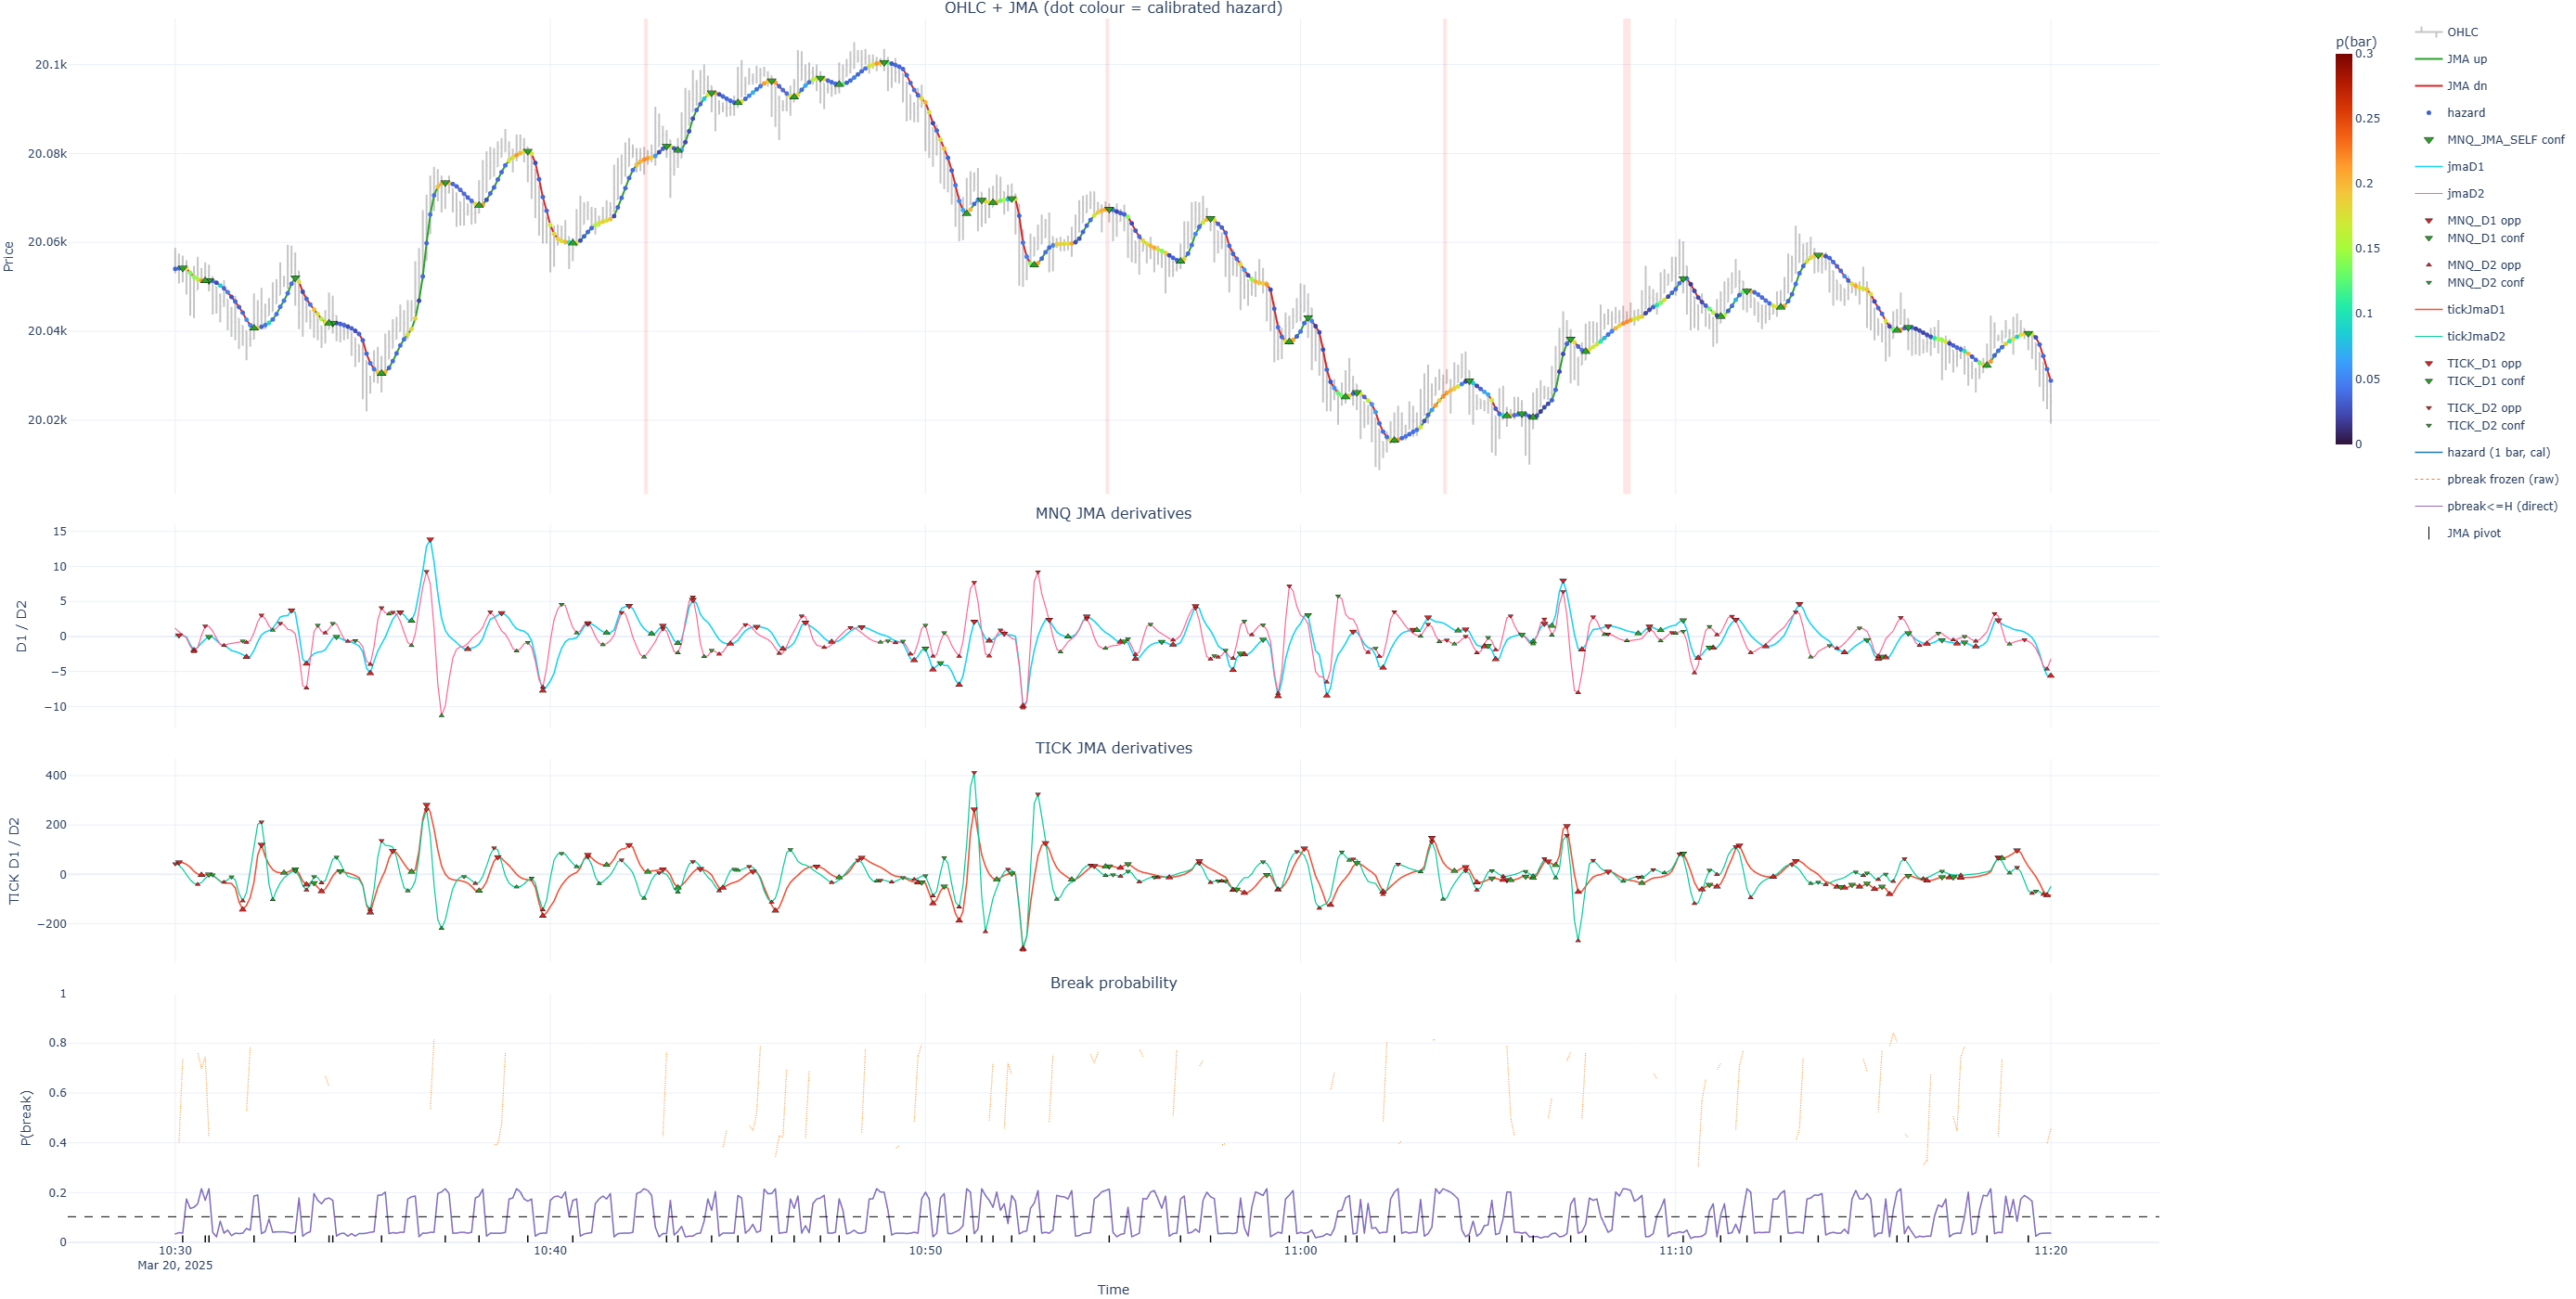

In [30]:
fig = plot_day_hawkes(d, ev, t_from="10:30", t_to="11:20")
add_hazard_bands(fig, d[(d.timestamp.dt.time >= pd.Timestamp("10:30").time()) &
                        (d.timestamp.dt.time <= pd.Timestamp("11:20").time())], thresh=0.204)
fig.show()

In [14]:
d.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 32 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   timestamp        3900 non-null   datetime64[us]
 1   Open             3900 non-null   float64       
 2   High             3900 non-null   float64       
 3   Low              3900 non-null   float64       
 4   Last             3900 non-null   float64       
 5   JMA              3900 non-null   float64       
 6   VEL              3900 non-null   float64       
 7   adpVEL           3900 non-null   float64       
 8   bolTopAdpVEL     3900 non-null   float64       
 9   bolMidAdpVEL     3900 non-null   float64       
 10  bolBotAdpVEL     3900 non-null   float64       
 11  RSX              3900 non-null   float64       
 12  tickRSX          3900 non-null   float64       
 13  jmaD1            3900 non-null   float64       
 14  jmaD2            3900 non-null   float64       
 15